# SQL Metrics Analysis for GTFS Service Gap Project

本 notebook 使用 DuckDB SQL 完成 GTFS 多表连接、核心服务指标聚合、路线级 Gap Score 计算和站点覆盖分析。Python/Pandas 主要用于 SQL 结果整理、图表绘制和 dashboard-ready 数据导出。

In [1]:
import sys

!{sys.executable} -m pip install duckdb
from pathlib import Path
import os
import zipfile
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# 找到项目根目录
def find_repo_root(start_path=Path.cwd()):
    current = start_path.resolve()
    for path in [current] + list(current.parents):
        if (path / "README.md").exists():
            return path
    return current

repo_root = find_repo_root()
os.chdir(repo_root)

print("当前项目根目录：", repo_root)

raw_dir = repo_root / "data" / "raw"
extract_dir = raw_dir / "current_gtfs"
output_dir = repo_root / "outputs"
sql_output_dir = output_dir / "sql_outputs"

raw_dir.mkdir(parents=True, exist_ok=True)
extract_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)
sql_output_dir.mkdir(parents=True, exist_ok=True)

zip_path = raw_dir / "tritontransit-ca-us.zip"

print("GTFS zip 是否存在：", zip_path.exists())
print("GTFS zip 路径：", zip_path)

当前项目根目录： C:\Users\Zev\Documents\GitHub\ucsd-triton-transit-evening-gap-analysis
GTFS zip 是否存在： True
GTFS zip 路径： C:\Users\Zev\Documents\GitHub\ucsd-triton-transit-evening-gap-analysis\data\raw\tritontransit-ca-us.zip


In [2]:
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("GTFS 文件解压完成，包含以下文件：")

for file in sorted(extract_dir.iterdir()):
    print("-", file.name)

GTFS 文件解压完成，包含以下文件：
- agency.txt
- calendar.txt
- calendar_dates.txt
- feed_info.txt
- routes.txt
- shapes.txt
- stop_times.txt
- stops.txt
- trips.txt


In [3]:
con = duckdb.connect()

con.execute("""
CREATE OR REPLACE VIEW routes AS
SELECT *
FROM read_csv_auto('data/raw/current_gtfs/routes.txt');

CREATE OR REPLACE VIEW trips AS
SELECT *
FROM read_csv_auto('data/raw/current_gtfs/trips.txt');

CREATE OR REPLACE VIEW stop_times AS
SELECT *
FROM read_csv_auto('data/raw/current_gtfs/stop_times.txt');

CREATE OR REPLACE VIEW stops AS
SELECT *
FROM read_csv_auto('data/raw/current_gtfs/stops.txt');

CREATE OR REPLACE VIEW calendar AS
SELECT *
FROM read_csv_auto('data/raw/current_gtfs/calendar.txt');

CREATE OR REPLACE VIEW calendar_dates AS
SELECT *
FROM read_csv_auto('data/raw/current_gtfs/calendar_dates.txt');
""")

print("GTFS tables loaded into DuckDB views.")

GTFS tables loaded into DuckDB views.


In [4]:
data_quality = con.execute("""
SELECT 'routes' AS table_name, COUNT(*) AS row_count FROM routes
UNION ALL
SELECT 'trips', COUNT(*) FROM trips
UNION ALL
SELECT 'stop_times', COUNT(*) FROM stop_times
UNION ALL
SELECT 'stops', COUNT(*) FROM stops
UNION ALL
SELECT 'calendar', COUNT(*) FROM calendar
UNION ALL
SELECT 'calendar_dates', COUNT(*) FROM calendar_dates;
""").df()

display(data_quality)

data_quality.to_csv(output_dir / "sql_data_quality_summary.csv", index=False)

,table_name,row_count
0,routes,6
1,trips,501
2,stop_times,7126
3,stops,60
4,calendar,4
5,calendar_dates,2


In [6]:
con.execute("""
CREATE OR REPLACE VIEW stop_times_clean AS
SELECT
    trip_id,
    arrival_time,
    departure_time,
    stop_id,
    stop_sequence,
    CASE
        WHEN arrival_time IS NULL THEN NULL
        ELSE
            CAST(split_part(CAST(arrival_time AS VARCHAR), ':', 1) AS INTEGER) * 60
            + CAST(split_part(CAST(arrival_time AS VARCHAR), ':', 2) AS INTEGER)
            + CAST(split_part(CAST(arrival_time AS VARCHAR), ':', 3) AS DOUBLE) / 60
    END AS arrival_min
FROM stop_times;
""")

display(con.execute("""
SELECT *
FROM stop_times_clean
LIMIT 10;
""").df())

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,arrival_min
0,ML_Weekday_T01,07:00:00,07:00:00,9912,1,420.0
1,ML_Weekday_T01,<NA>,<NA>,9913,2,NaN
2,ML_Weekday_T01,<NA>,<NA>,9915,3,NaN
3,ML_Weekday_T01,<NA>,<NA>,9916,4,NaN
4,ML_Weekday_T01,<NA>,<NA>,9903,5,NaN
5,ML_Weekday_T01,07:10:00,07:10:00,10772,6,430.0
6,ML_Weekday_T01,<NA>,<NA>,9908,7,NaN
7,ML_Weekday_T01,<NA>,<NA>,10378,8,NaN
8,ML_Weekday_T01,<NA>,<NA>,9917,9,NaN
9,ML_Weekday_T01,<NA>,<NA>,9918,10,NaN


In [7]:
con.execute("""
CREATE OR REPLACE VIEW trip_time_summary AS
SELECT
    trip_id,
    MIN(arrival_min) AS trip_start_min,
    MAX(arrival_min) AS trip_end_min,
    COUNT(arrival_min) AS timepoint_count,
    CAST(FLOOR(MIN(arrival_min) / 60) AS INTEGER) AS trip_start_hour,
    CAST(FLOOR(MAX(arrival_min) / 60) AS INTEGER) AS trip_end_hour
FROM stop_times_clean
WHERE arrival_min IS NOT NULL
GROUP BY trip_id;

CREATE OR REPLACE VIEW trip_service_master AS
SELECT
    t.trip_id,
    t.route_id,
    t.service_id,
    t.trip_headsign,
    t.direction_id,
    r.route_short_name,
    r.route_long_name,
    CONCAT(
        COALESCE(CAST(r.route_short_name AS VARCHAR), ''),
        ' - ',
        COALESCE(CAST(r.route_long_name AS VARCHAR), '')
    ) AS route_name,
    ts.trip_start_min,
    ts.trip_end_min,
    ts.trip_start_hour,
    ts.trip_end_hour,
    CASE
        WHEN ts.trip_start_hour BETWEEN 17 AND 21 THEN 1
        ELSE 0
    END AS is_evening_trip
FROM trips t
LEFT JOIN trip_time_summary ts
    ON t.trip_id = ts.trip_id
LEFT JOIN routes r
    ON t.route_id = r.route_id;

CREATE OR REPLACE VIEW weekday_trips AS
SELECT *
FROM trip_service_master
WHERE service_id = 'Weekday';
""")

weekday_preview = con.execute("""
SELECT *
FROM weekday_trips
LIMIT 10;
""").df()

display(weekday_preview)

,trip_id,route_id,service_id,trip_headsign,direction_id,route_short_name,route_long_name,route_name,trip_start_min,trip_end_min,trip_start_hour,trip_end_hour,is_evening_trip
0,ML_Weekday_T05,1050,Weekday,Mesa Loop,1,ML,Mesa Loop,ML - Mesa Loop,460.0,485.0,7,8,0
1,ML_Weekday_T15,1050,Weekday,Mesa Loop,1,ML,Mesa Loop,ML - Mesa Loop,560.0,585.0,9,9,0
2,ML_Weekday_T17,1050,Weekday,Mesa Loop,1,ML,Mesa Loop,ML - Mesa Loop,580.0,605.0,9,10,0
3,ML_Weekday_T34,1050,Weekday,Mesa Loop,1,ML,Mesa Loop,ML - Mesa Loop,750.0,775.0,12,12,0
4,ML_Weekday_T41,1050,Weekday,Mesa Loop,1,ML,Mesa Loop,ML - Mesa Loop,820.0,845.0,13,14,0
5,OL_Weekday_T03,1030,Weekday,Outside Loop,1,OL,Outside Loop,OL - Outside Loop,450.0,475.0,7,7,0
6,OL_Weekday_T15,1030,Weekday,Outside Loop,1,OL,Outside Loop,OL - Outside Loop,630.0,655.0,10,10,0
7,OL_Weekday_T37,1030,Weekday,Outside Loop,1,OL,Outside Loop,OL - Outside Loop,960.0,985.0,16,16,0
8,OL_Weekday_T40,1030,Weekday,Outside Loop,1,OL,Outside Loop,OL - Outside Loop,1005.0,1030.0,16,17,0
9,IL_Weekday_T06,1040,Weekday,Inside Loop,1,IL,Inside Loop,IL - Inside Loop,495.0,522.0,8,8,0


In [8]:
con.execute("""
CREATE OR REPLACE VIEW hourly_service_frequency_weekday AS
SELECT
    trip_start_hour,
    COUNT(DISTINCT trip_id) AS hourly_service_frequency,
    60.0 / COUNT(DISTINCT trip_id) AS estimated_headway_min,
    CASE
        WHEN trip_start_hour BETWEEN 17 AND 21 THEN 1
        ELSE 0
    END AS is_evening_hour
FROM weekday_trips
WHERE trip_start_hour IS NOT NULL
GROUP BY trip_start_hour
ORDER BY trip_start_hour;
""")

sql_hourly_service = con.execute("""
SELECT *
FROM hourly_service_frequency_weekday
ORDER BY trip_start_hour;
""").df()

display(sql_hourly_service)

,trip_start_hour,hourly_service_frequency,estimated_headway_min,is_evening_hour
0,7,24,2.500000,0
1,8,24,2.500000,0
2,9,24,2.500000,0
3,10,24,2.500000,0
4,11,24,2.500000,0
5,12,24,2.500000,0
6,13,24,2.500000,0
7,14,24,2.500000,0
8,15,24,2.500000,0
9,16,24,2.500000,0


In [9]:
con.execute("""
CREATE OR REPLACE VIEW evening_hour_gap_ranking AS
SELECT
    CONCAT(
        LPAD(CAST(trip_start_hour AS VARCHAR), 2, '0'),
        ':00-',
        LPAD(CAST(trip_start_hour + 1 AS VARCHAR), 2, '0'),
        ':00'
    ) AS hour_range,
    trip_start_hour,
    hourly_service_frequency,
    estimated_headway_min
FROM hourly_service_frequency_weekday
WHERE is_evening_hour = 1
ORDER BY hourly_service_frequency ASC;
""")

sql_evening_hour_gap = con.execute("""
SELECT *
FROM evening_hour_gap_ranking;
""").df()

display(sql_evening_hour_gap)

,hour_range,trip_start_hour,hourly_service_frequency,estimated_headway_min
0,21:00-22:00,21,10,6.000000
1,20:00-21:00,20,13,4.615385
2,19:00-20:00,19,17,3.529412
3,18:00-19:00,18,23,2.608696
4,17:00-18:00,17,24,2.500000


In [10]:
con.execute("""
CREATE OR REPLACE VIEW route_service_summary_weekday AS
SELECT
    route_id,
    route_name,
    COUNT(DISTINCT trip_id) AS total_trips,
    SUM(is_evening_trip) AS evening_trips,
    SUM(is_evening_trip) * 1.0 / COUNT(DISTINCT trip_id) AS evening_service_share,
    MIN(trip_start_min) AS first_trip_min,
    MAX(trip_start_min) AS last_trip_min,
    (MAX(trip_start_min) - MIN(trip_start_min)) / 60.0 AS service_span_hours,
    CASE
        WHEN SUM(is_evening_trip) > 0 THEN 300.0 / SUM(is_evening_trip)
        ELSE NULL
    END AS estimated_evening_headway_min
FROM weekday_trips
WHERE trip_start_min IS NOT NULL
GROUP BY route_id, route_name;
""")

sql_route_service_summary = con.execute("""
SELECT
    *,
    CONCAT(
        LPAD(CAST(CAST(FLOOR(first_trip_min / 60) AS INTEGER) AS VARCHAR), 2, '0'),
        ':',
        LPAD(CAST(CAST(first_trip_min AS INTEGER) % 60 AS VARCHAR), 2, '0')
    ) AS first_trip_time,
    CONCAT(
        LPAD(CAST(CAST(FLOOR(last_trip_min / 60) AS INTEGER) AS VARCHAR), 2, '0'),
        ':',
        LPAD(CAST(CAST(last_trip_min AS INTEGER) % 60 AS VARCHAR), 2, '0')
    ) AS last_trip_time
FROM route_service_summary_weekday
ORDER BY estimated_evening_headway_min DESC;
""").df()

display(sql_route_service_summary)

,route_id,route_name,total_trips,evening_trips,evening_service_share,first_trip_min,last_trip_min,service_span_hours,estimated_evening_headway_min,first_trip_time,last_trip_time
0,1020,S - SIO Shuttle,53,13.0,0.245283,420.0,1230.0,13.500000,23.076923,07:00,20:30
1,1030,OL - Outside Loop,55,15.0,0.272727,420.0,1290.0,14.500000,20.000000,07:00,21:30
2,1040,IL - Inside Loop,59,19.0,0.322034,420.0,1305.0,14.750000,15.789474,07:00,21:45
3,1050,ML - Mesa Loop,80,20.0,0.250000,420.0,1290.0,14.500000,15.000000,07:00,21:30
4,1010,R - Regents Express,81,20.0,0.246914,420.0,1330.0,15.166667,15.000000,07:00,22:10


In [11]:
con.execute("""
CREATE OR REPLACE VIEW route_evening_hourly_service_weekday AS
SELECT
    route_id,
    route_name,
    trip_start_hour,
    COUNT(DISTINCT trip_id) AS hourly_trips,
    60.0 / COUNT(DISTINCT trip_id) AS estimated_headway_min
FROM weekday_trips
WHERE trip_start_hour BETWEEN 17 AND 21
GROUP BY route_id, route_name, trip_start_hour
ORDER BY route_name, trip_start_hour;
""")

sql_route_evening_hourly = con.execute("""
SELECT *
FROM route_evening_hourly_service_weekday;
""").df()

display(sql_route_evening_hourly)

,route_id,route_name,trip_start_hour,hourly_trips,estimated_headway_min
0,1040,IL - Inside Loop,17,4,15.0
1,1040,IL - Inside Loop,18,4,15.0
2,1040,IL - Inside Loop,19,4,15.0
3,1040,IL - Inside Loop,20,4,15.0
4,1040,IL - Inside Loop,21,3,20.0
5,1050,ML - Mesa Loop,17,6,10.0
6,1050,ML - Mesa Loop,18,6,10.0
7,1050,ML - Mesa Loop,19,4,15.0
8,1050,ML - Mesa Loop,20,2,30.0
9,1050,ML - Mesa Loop,21,2,30.0


In [12]:
con.execute("""
CREATE OR REPLACE VIEW route_gap_score_base AS
SELECT
    *,
    CASE
        WHEN MAX(estimated_evening_headway_min) OVER () = MIN(estimated_evening_headway_min) OVER ()
        THEN 0
        ELSE
            (estimated_evening_headway_min - MIN(estimated_evening_headway_min) OVER ())
            / NULLIF(
                MAX(estimated_evening_headway_min) OVER () - MIN(estimated_evening_headway_min) OVER (),
                0
            )
    END AS headway_score,

    LEAST(
        GREATEST((22 * 60 - last_trip_min) / 120.0, 0),
        1
    ) AS early_last_trip_score,

    1 -
    CASE
        WHEN MAX(evening_service_share) OVER () = MIN(evening_service_share) OVER ()
        THEN 0
        ELSE
            (evening_service_share - MIN(evening_service_share) OVER ())
            / NULLIF(
                MAX(evening_service_share) OVER () - MIN(evening_service_share) OVER (),
                0
            )
    END AS low_evening_share_score
FROM route_service_summary_weekday;
""")

con.execute("""
CREATE OR REPLACE VIEW route_evening_gap_score_weekday AS
SELECT
    route_id,
    route_name,
    total_trips,
    evening_trips,
    evening_service_share,
    estimated_evening_headway_min,
    first_trip_min,
    last_trip_min,
    service_span_hours,
    headway_score,
    early_last_trip_score,
    low_evening_share_score,
    0.40 * headway_score
        + 0.35 * early_last_trip_score
        + 0.25 * low_evening_share_score AS evening_gap_score,
    CASE
        WHEN 0.40 * headway_score
            + 0.35 * early_last_trip_score
            + 0.25 * low_evening_share_score >= 0.70
        THEN 'P1 - high priority'
        WHEN 0.40 * headway_score
            + 0.35 * early_last_trip_score
            + 0.25 * low_evening_share_score >= 0.40
        THEN 'P2 - medium priority'
        ELSE 'P3 - low priority'
    END AS optimization_priority
FROM route_gap_score_base
ORDER BY evening_gap_score DESC;
""")

sql_route_gap = con.execute("""
SELECT
    route_name,
    total_trips,
    evening_trips,
    ROUND(evening_service_share, 3) AS evening_service_share,
    ROUND(estimated_evening_headway_min, 2) AS estimated_evening_headway_min,
    CONCAT(
        LPAD(CAST(CAST(FLOOR(last_trip_min / 60) AS INTEGER) AS VARCHAR), 2, '0'),
        ':',
        LPAD(CAST(CAST(last_trip_min AS INTEGER) % 60 AS VARCHAR), 2, '0')
    ) AS last_trip_time,
    ROUND(headway_score, 3) AS headway_score,
    ROUND(early_last_trip_score, 3) AS early_last_trip_score,
    ROUND(low_evening_share_score, 3) AS low_evening_share_score,
    ROUND(evening_gap_score, 3) AS evening_gap_score,
    optimization_priority
FROM route_evening_gap_score_weekday;
""").df()

display(sql_route_gap)

,route_name,total_trips,evening_trips,evening_service_share,estimated_evening_headway_min,last_trip_time,headway_score,early_last_trip_score,low_evening_share_score,evening_gap_score,optimization_priority
0,S - SIO Shuttle,53,13.0,0.245,23.08,20:30,1.000,0.750,1.000,0.913,P1 - high priority
1,OL - Outside Loop,55,15.0,0.273,20.00,21:30,0.619,0.250,0.642,0.496,P2 - medium priority
2,ML - Mesa Loop,80,20.0,0.250,15.00,21:30,0.000,0.250,0.939,0.322,P3 - low priority
3,R - Regents Express,81,20.0,0.247,15.00,22:10,0.000,0.000,0.979,0.245,P3 - low priority
4,IL - Inside Loop,59,19.0,0.322,15.79,21:45,0.098,0.125,0.000,0.083,P3 - low priority


In [13]:
con.execute("""
CREATE OR REPLACE VIEW stop_service_master AS
SELECT
    st.trip_id,
    st.stop_id,
    s.stop_name,
    s.stop_lat,
    s.stop_lon,
    t.route_id,
    t.route_name,
    t.service_id,
    t.trip_start_hour,
    CASE
        WHEN t.trip_start_hour BETWEEN 17 AND 21 THEN 1
        ELSE 0
    END AS is_evening_stop_visit
FROM stop_times st
LEFT JOIN stops s
    ON st.stop_id = s.stop_id
LEFT JOIN trip_service_master t
    ON st.trip_id = t.trip_id;
""")

con.execute("""
CREATE OR REPLACE VIEW stop_service_summary_weekday AS
SELECT
    stop_id,
    stop_name,
    stop_lat,
    stop_lon,
    COUNT(*) AS total_visits,
    SUM(is_evening_stop_visit) AS evening_visits,
    SUM(is_evening_stop_visit) * 1.0 / COUNT(*) AS evening_coverage_rate,
    STRING_AGG(DISTINCT route_name, ', ') AS routes_serving_stop
FROM stop_service_master
WHERE service_id = 'Weekday'
GROUP BY stop_id, stop_name, stop_lat, stop_lon
ORDER BY evening_coverage_rate ASC, total_visits DESC;
""")

sql_stop_service_summary = con.execute("""
SELECT *
FROM stop_service_summary_weekday
ORDER BY evening_coverage_rate ASC, total_visits DESC
LIMIT 15;
""").df()

display(sql_stop_service_summary)

,stop_id,stop_name,stop_lat,stop_lon,total_visits,evening_visits,evening_coverage_rate,routes_serving_stop
0,3055,Nierenberg Hall,32.869245,-117.251025,53,13.0,0.245283,S - SIO Shuttle
1,3065,Coast Apartments (South),32.869010,-117.246914,53,13.0,0.245283,S - SIO Shuttle
2,12284,Vaughan Hall,32.865726,-117.252189,53,13.0,0.245283,S - SIO Shuttle
3,11528,Coast Apartments (West),32.869563,-117.248512,53,13.0,0.245283,S - SIO Shuttle
4,11850,IGPP,32.867439,-117.252156,53,13.0,0.245283,S - SIO Shuttle
5,3070,Expedition Wy & Capricorn Ln,32.870854,-117.243758,53,13.0,0.245283,S - SIO Shuttle
6,3005,UCSD Extended Studies Building (North),32.871886,-117.234716,53,13.0,0.245283,S - SIO Shuttle
7,11873,La Jolla Shores Dr & Inyaha Ln,32.874076,-117.244956,53,13.0,0.245283,S - SIO Shuttle
8,3040,Eckart Building / Hubbs Hall,32.866324,-117.252712,53,13.0,0.245283,S - SIO Shuttle
9,3045,Scripps Seaside Forum / Beach,32.865352,-117.253931,53,13.0,0.245283,S - SIO Shuttle


In [14]:
sql_output_dir = repo_root / "outputs" / "sql_outputs"
sql_output_dir.mkdir(parents=True, exist_ok=True)

sql_exports = {
    "sql_data_quality_summary.csv": data_quality,
    "sql_hourly_service_frequency_weekday.csv": sql_hourly_service,
    "sql_evening_hour_gap_ranking.csv": sql_evening_hour_gap,
    "sql_route_service_summary_weekday.csv": sql_route_service_summary,
    "sql_route_evening_hourly_service_weekday.csv": sql_route_evening_hourly,
    "sql_route_evening_gap_score_weekday.csv": sql_route_gap,
    "sql_stop_service_summary_weekday_top15.csv": sql_stop_service_summary
}

for file_name, df in sql_exports.items():
    df.to_csv(sql_output_dir / file_name, index=False)
    print(file_name, df.shape)

print("SQL 分析结果已导出到 outputs/sql_outputs/")

sql_data_quality_summary.csv (6, 2)
sql_hourly_service_frequency_weekday.csv (16, 4)
sql_evening_hour_gap_ranking.csv (5, 4)
sql_route_service_summary_weekday.csv (5, 11)
sql_route_evening_hourly_service_weekday.csv (24, 5)
sql_route_evening_gap_score_weekday.csv (5, 11)
sql_stop_service_summary_weekday_top15.csv (15, 8)
SQL 分析结果已导出到 outputs/sql_outputs/


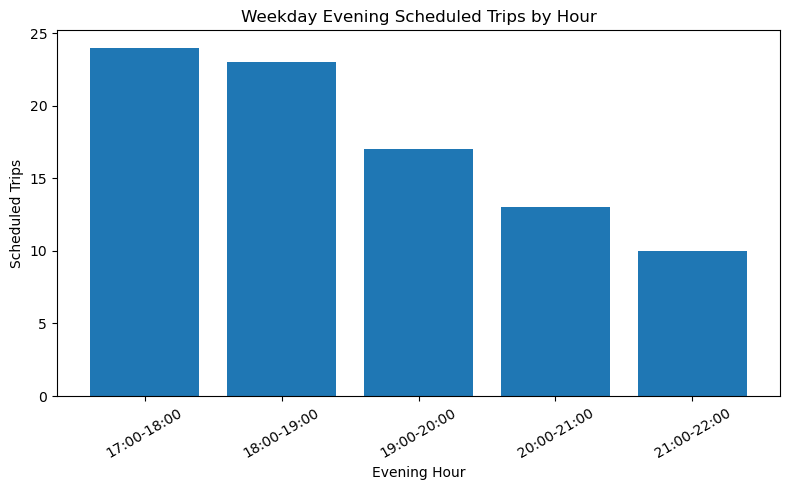

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    sql_evening_hour_gap.sort_values("trip_start_hour")["hour_range"],
    sql_evening_hour_gap.sort_values("trip_start_hour")["hourly_service_frequency"]
)

plt.xlabel("Evening Hour")
plt.ylabel("Scheduled Trips")
plt.title("Weekday Evening Scheduled Trips by Hour")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(output_dir / "chart_sql_evening_hourly_service.png", dpi=200)
plt.show()

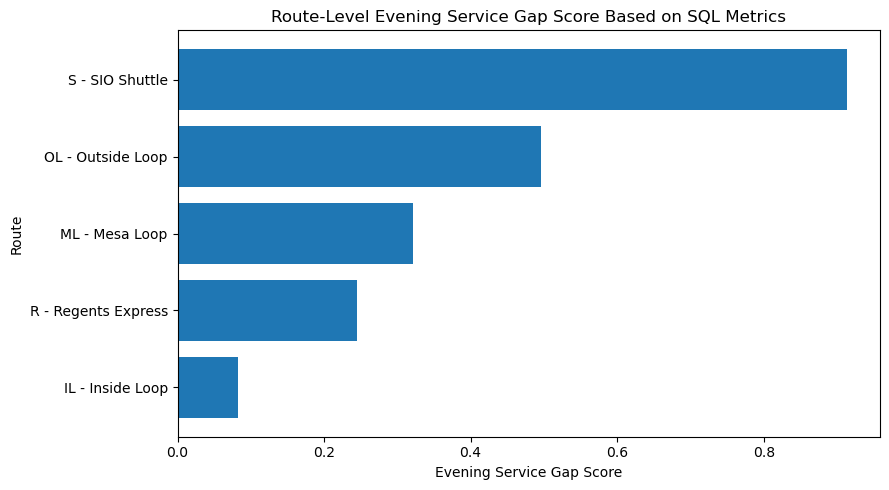

In [16]:
route_gap_plot = sql_route_gap.sort_values("evening_gap_score", ascending=True)

plt.figure(figsize=(9, 5))

plt.barh(
    route_gap_plot["route_name"],
    route_gap_plot["evening_gap_score"]
)

plt.xlabel("Evening Service Gap Score")
plt.ylabel("Route")
plt.title("Route-Level Evening Service Gap Score Based on SQL Metrics")
plt.tight_layout()

plt.savefig(output_dir / "chart_sql_route_gap_score.png", dpi=200)
plt.show()

trip_start_hour,17,18,19,20,21
route_name,,,,,
IL - Inside Loop,4,4,4,4,3
ML - Mesa Loop,6,6,4,2,2
OL - Outside Loop,4,4,3,2,2
R - Regents Express,6,5,3,3,3
S - SIO Shuttle,4,4,3,2,0


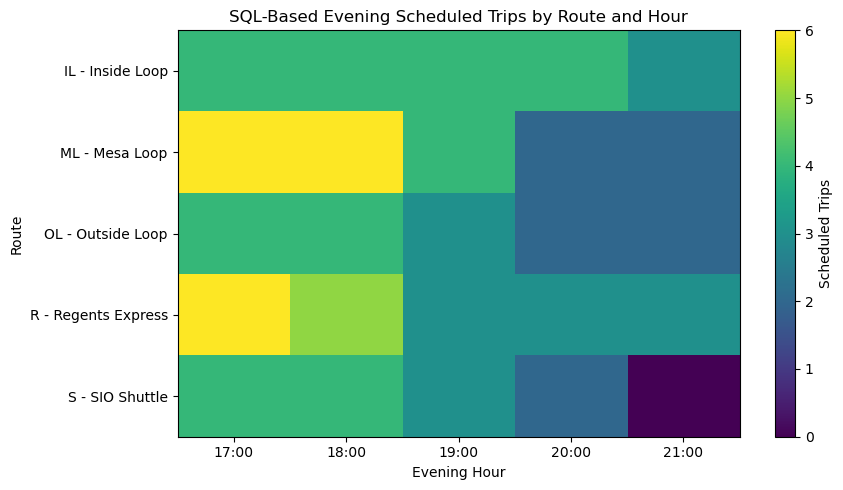

In [17]:
route_hour_pivot_sql = sql_route_evening_hourly.pivot_table(
    index="route_name",
    columns="trip_start_hour",
    values="hourly_trips",
    aggfunc="sum",
    fill_value=0
)

display(route_hour_pivot_sql)

plt.figure(figsize=(9, 5))

plt.imshow(route_hour_pivot_sql, aspect="auto")

plt.xticks(
    range(len(route_hour_pivot_sql.columns)),
    [str(int(h)) + ":00" for h in route_hour_pivot_sql.columns]
)

plt.yticks(
    range(len(route_hour_pivot_sql.index)),
    route_hour_pivot_sql.index
)

plt.xlabel("Evening Hour")
plt.ylabel("Route")
plt.title("SQL-Based Evening Scheduled Trips by Route and Hour")
plt.colorbar(label="Scheduled Trips")
plt.tight_layout()

plt.savefig(output_dir / "chart_sql_route_hour_heatmap.png", dpi=200)
plt.show()

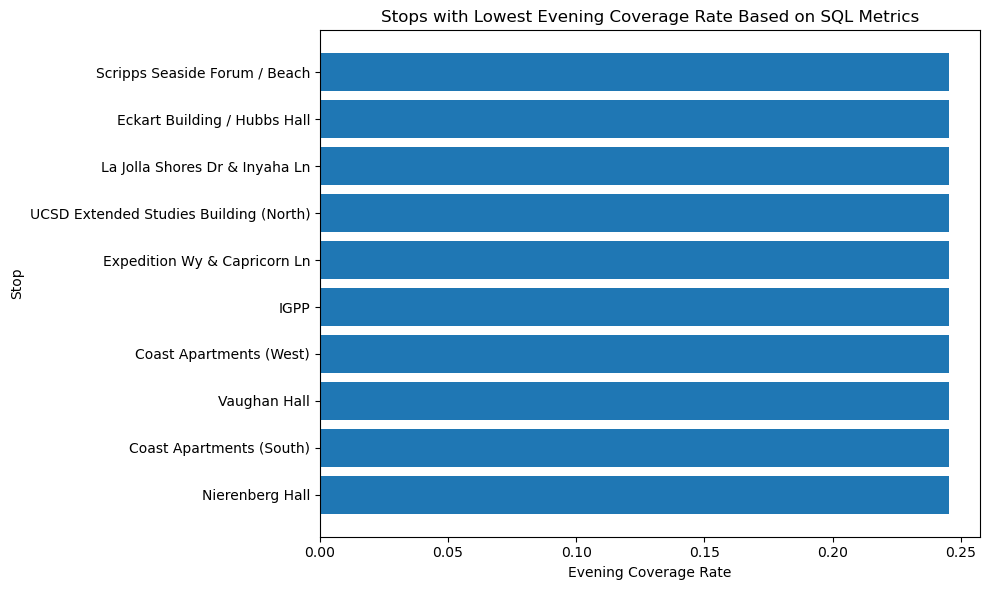

In [18]:
stop_gap_plot = sql_stop_service_summary.sort_values(
    "evening_coverage_rate",
    ascending=True
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    stop_gap_plot["stop_name"],
    stop_gap_plot["evening_coverage_rate"]
)

plt.xlabel("Evening Coverage Rate")
plt.ylabel("Stop")
plt.title("Stops with Lowest Evening Coverage Rate Based on SQL Metrics")
plt.tight_layout()

plt.savefig(output_dir / "chart_sql_stop_evening_coverage.png", dpi=200)
plt.show()

In [19]:
dashboard_sql_dir = repo_root / "dashboard_data" / "sql_based"
dashboard_sql_dir.mkdir(parents=True, exist_ok=True)

sql_evening_hour_gap.to_csv(
    dashboard_sql_dir / "dashboard_sql_hourly_evening_gap.csv",
    index=False
)

sql_route_gap.to_csv(
    dashboard_sql_dir / "dashboard_sql_route_gap_score.csv",
    index=False
)

sql_route_evening_hourly.to_csv(
    dashboard_sql_dir / "dashboard_sql_route_hourly_service.csv",
    index=False
)

sql_stop_service_summary.to_csv(
    dashboard_sql_dir / "dashboard_sql_stop_evening_coverage.csv",
    index=False
)

print("SQL-based dashboard data exported.")

SQL-based dashboard data exported.


In [21]:
top_hour_sql = sql_evening_hour_gap.iloc[0]
top_route_sql = sql_route_gap.iloc[0]
top_stop_sql = sql_stop_service_summary.iloc[0]

sql_summary_text = f"""
SQL + Python analysis summary:

1. The lowest evening service hour is {top_hour_sql['hour_range']}, with {int(top_hour_sql['hourly_service_frequency'])} scheduled trips.

2. The route with the highest Evening Service Gap Score is {top_route_sql['route_name']}.
It has {int(top_route_sql['evening_trips'])} evening trips, an estimated evening headway of {top_route_sql['estimated_evening_headway_min']} minutes, and a last trip time of {top_route_sql['last_trip_time']}.

3. The stop with the lowest evening coverage among the SQL output is {top_stop_sql['stop_name']}.
It has {int(top_stop_sql['total_visits'])} total weekday visits and {int(top_stop_sql['evening_visits'])} evening visits.

4. SQL was used for GTFS multi-table joins, time conversion, service aggregation, route-level scoring, and stop-level coverage analysis.
Python/Pandas was used for result organization, visualization, dashboard-ready outputs, and optimization simulation.
"""

print(sql_summary_text)

with open(output_dir / "sql_analysis_summary.txt", "w", encoding="utf-8") as f:
    f.write(sql_summary_text)


SQL + Python analysis summary:

1. The lowest evening service hour is 21:00-22:00, with 10 scheduled trips.

2. The route with the highest Evening Service Gap Score is S - SIO Shuttle.
It has 13 evening trips, an estimated evening headway of 23.08 minutes, and a last trip time of 20:30.

3. The stop with the lowest evening coverage among the SQL output is Nierenberg Hall.
It has 53 total weekday visits and 13 evening visits.

4. SQL was used for GTFS multi-table joins, time conversion, service aggregation, route-level scoring, and stop-level coverage analysis.
Python/Pandas was used for result organization, visualization, dashboard-ready outputs, and optimization simulation.

